In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import os
from torch.utils.data import Dataset, DataLoader
from rdkit import Chem
import selfies  # Ensure you have installed selfies (pip install selfies)

In [2]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import PandasTools
from tqdm import tqdm

# Load QM9 CSV file (make sure qm9.csv is in the same folder)
df = pd.read_csv('qm9.csv')

# Ensure it has a column named 'smiles'
assert 'smiles' in df.columns, "CSV must have a 'smiles' column."

# Convert SMILES to RDKit Mol objects
PandasTools.AddMoleculeColumnToFrame(df, smilesCol='smiles')

In [3]:
def generate_unique_pairs(base_smiles_list, acid_smiles_list, max_pairs):
    seen = set()
    unique_pairs = []

    while len(unique_pairs) < max_pairs:
        b = random.choice(base_smiles_list)
        a = random.choice(acid_smiles_list)
        pair_key = (b, a)

        if pair_key not in seen:
            seen.add(pair_key)
            unique_pairs.append({'flp_smiles': f"{b}.{a}", 'type': 'inter'})

        # Optional: break early if we've exhausted all possible unique pairs
        if len(seen) >= len(base_smiles_list) * len(acid_smiles_list):
            break

    return unique_pairs

In [4]:
from rdkit import Chem
import pandas as pd
import random

def has_carbon_oxygen(mol):
    """Returns True if the molecule has at least one C and one O."""
    if mol is None:
        return False
    carbon = oxygen = 0
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() == 6:
            carbon += 1
        elif atom.GetAtomicNum() == 8:
            oxygen += 1
    return carbon >= 1 and oxygen >= 1

def is_lewis_base(mol):
    """Checks if molecule has a Lewis base site (N or P with lone pair)."""
    if mol is None or not has_carbon_oxygen(mol):
        return False
    for atom in mol.GetAtoms():
        if atom.GetAtomicNum() in [7, 15]:  # N, P
            if atom.GetTotalDegree() >= 1 and atom.GetFormalCharge() <= 0:
                return True
    return False

def is_lewis_acid(mol):
    """Checks if molecule has a Lewis acid site (Boron, carbonyl C, or cation)."""
    if mol is None or not has_carbon_oxygen(mol):
        return False
    for atom in mol.GetAtoms():
        num = atom.GetAtomicNum()
        if num == 5 and atom.GetTotalDegree() <= 3:
            return True  # Boron
        if num == 6:
            neighbors = [nbr.GetAtomicNum() for nbr in atom.GetNeighbors()]
            if atom.GetHybridization() == Chem.HybridizationType.SP2 and 8 in neighbors:
                return True  # C=O carbon
        if atom.GetFormalCharge() > 0:
            return True  # Positively charged site
    return False

def is_intramolecular_flp(mol):
    """Returns True if molecule has both base and acid sites (intramolecular FLP)."""
    return is_lewis_base(mol) and is_lewis_acid(mol)

def extract_all_flps(df, max_pairs=None):
    """
    Extracts both intramolecular FLPs and intermolecular FLP pairs (carbon + oxygen required).

    Args:
        df (pd.DataFrame): QM9 DataFrame with 'ROMol' and 'smiles' columns.
        max_pairs (int, optional): Max number of intermolecular pairs to generate.

    Returns:
        pd.DataFrame: Combined FLP candidates with a 'type' column: 'intra' or 'inter'.
    """
    print("🔎 Filtering intramolecular FLPs...")
    intra_df = df[df['ROMol'].apply(is_intramolecular_flp)].copy()
    intra_df['flp_smiles'] = intra_df['smiles']
    intra_df['type'] = 'intra'

    print(f"✅ Found {len(intra_df)} intramolecular FLPs.")

    print("🔎 Filtering Lewis bases and acids for intermolecular FLPs...")
    bases_df = df[df['ROMol'].apply(is_lewis_base)].copy()
    acids_df = df[df['ROMol'].apply(is_lewis_acid)].copy()

    print(f"✅ Found {len(bases_df)} bases and {len(acids_df)} acids for pairing.")

    # Build intermolecular pairs
    inter_data = []
    if not bases_df.empty and not acids_df.empty:
        base_smiles = bases_df['smiles'].tolist()
        acid_smiles = acids_df['smiles'].tolist()
        if max_pairs:
            seen = set()
            while len(inter_data) < max_pairs:
                b = random.choice(base_smiles)
                a = random.choice(acid_smiles)
                key = (b, a)
                if key not in seen:
                    seen.add(key)
                    inter_data.append({'flp_smiles': f"{b}.{a}", 'type': 'inter'})

                if len(seen) >= len(base_smiles) * len(acid_smiles):
                    break  # all unique pairs exhausted

        else:
            seen = set()
            for b in base_smiles:
                for a in acid_smiles:
                    pair_key = (b, a)
                    if pair_key not in seen:
                        seen.add(pair_key)
                        inter_data.append({'flp_smiles': f"{b}.{a}", 'type': 'inter'})

    inter_df = pd.DataFrame(inter_data)

    print(f"✅ Generated {len(inter_df)} intermolecular FLP pairs.")

    # Combine both
    combined_df = pd.concat([intra_df[['flp_smiles', 'type']], inter_df], ignore_index=True)
    print(f"🔗 Total FLP candidates: {len(combined_df)}")

    return combined_df

# Example use:
print("Extracting all FLP candidates (intra + inter)...")
flp_all_df = extract_all_flps(df, max_pairs=60000)
print(flp_all_df.head())

Extracting all FLP candidates (intra + inter)...
🔎 Filtering intramolecular FLPs...
✅ Found 48699 intramolecular FLPs.
🔎 Filtering Lewis bases and acids for intermolecular FLPs...
✅ Found 67048 bases and 66805 acids for pairing.
✅ Generated 60000 intermolecular FLP pairs.
🔗 Total FLP candidates: 108699
  flp_smiles   type
0     C(=O)N  intra
1    CC(=O)N  intra
2  C(=O)(N)N  intra
3   C(=O)C#N  intra
4      CNC=O  intra


In [5]:
from rdkit import Chem
from rdkit.Chem import Descriptors
from rdkit.Chem.rdPartialCharges import ComputeGasteigerCharges

def extract_flp_features(flp_smiles):
    features = {
        'charge_diff': None,
        'tpsa': None,
        'rotatable_bonds': None,
        'num_rings': None
    }

    try:
        if '.' in flp_smiles:
            # Intermolecular FLP pair: split into base + acid
            base_smiles, acid_smiles = flp_smiles.split('.')
            base_mol = Chem.MolFromSmiles(base_smiles)
            acid_mol = Chem.MolFromSmiles(acid_smiles)
            if base_mol is None or acid_mol is None:
                return features

            # Add Hs + charges
            base = Chem.AddHs(base_mol)
            acid = Chem.AddHs(acid_mol)
            ComputeGasteigerCharges(base)
            ComputeGasteigerCharges(acid)

            base_charges = [float(atom.GetProp('_GasteigerCharge')) for atom in base.GetAtoms()]
            acid_charges = [float(atom.GetProp('_GasteigerCharge')) for atom in acid.GetAtoms()]
            features['charge_diff'] = abs(max(base_charges) - min(acid_charges))

            # Sum properties
            features['tpsa'] = Descriptors.TPSA(base) + Descriptors.TPSA(acid)
            features['rotatable_bonds'] = Descriptors.NumRotatableBonds(base) + Descriptors.NumRotatableBonds(acid)
            features['num_rings'] = base.GetRingInfo().NumRings() + acid.GetRingInfo().NumRings()

        else:
            # Intramolecular FLP: single molecule
            mol = Chem.MolFromSmiles(flp_smiles)
            if mol is None:
                return features

            mol = Chem.AddHs(mol)
            ComputeGasteigerCharges(mol)
            charges = [float(atom.GetProp('_GasteigerCharge')) for atom in mol.GetAtoms()]
            # Charge diff: max minus min in same molecule
            features['charge_diff'] = abs(max(charges) - min(charges))

            # Single-molecule descriptors
            features['tpsa'] = Descriptors.TPSA(mol)
            features['rotatable_bonds'] = Descriptors.NumRotatableBonds(mol)
            features['num_rings'] = mol.GetRingInfo().NumRings()

    except Exception as e:
        print("⚠️ Feature extraction failed for:", flp_smiles, "| Error:", e)

    return features

In [6]:
# Apply to flp_all_df
flp_feature_dicts = flp_all_df['flp_smiles'].apply(extract_flp_features)
flp_features_df = pd.DataFrame(flp_feature_dicts.tolist())

# Combine with original dataframe
flp_all_features_df = pd.concat([flp_all_df, flp_features_df], axis=1)

print(flp_all_features_df.head())

  flp_smiles   type  charge_diff   tpsa  rotatable_bonds  num_rings
0     C(=O)N  intra     0.576294  43.09                0          0
1    CC(=O)N  intra     0.583711  43.09                1          0
2  C(=O)(N)N  intra     0.660903  69.11                0          0
3   C(=O)C#N  intra     0.505340  40.86                0          0
4      CNC=O  intra     0.568116  29.10                1          0


In [7]:
flp_features_df

,charge_diff,tpsa,rotatable_bonds,num_rings
0,0.576294,43.09,0,0
1,0.583711,43.09,1,0
2,0.660903,69.11,0,0
3,0.505340,40.86,0,0
4,0.568116,29.10,1,0
...,...,...,...,...
108694,0.675774,109.48,8,1
108695,0.712023,158.39,1,2
108696,0.735245,87.99,3,3
108697,0.573001,116.49,4,2


In [9]:
# --------------------
# Data Preprocessing: Convert SMILES to tokenized SELFIES
# --------------------

class MolecularSELFIESDataset(Dataset):
    def __init__(self, smiles_list):
        self.smiles = smiles_list

        # Convert each SMILES to its tokenized SELFIES representation
        self.selfies_tokens_list = [self.smiles_to_selfies_tokens(smi) for smi in self.smiles]

        # Build vocabulary from all tokens (reserve index 0 for padding)
        all_tokens = [token for tokens in self.selfies_tokens_list for token in tokens]
        unique_tokens = sorted(set(all_tokens))
        self.token_to_idx = {token: idx + 1 for idx, token in enumerate(unique_tokens)}
        self.idx_to_token = {idx: token for token, idx in self.token_to_idx.items()}

        # Determine maximum sequence length for padding
        self.max_seq_len = max(len(tokens) for tokens in self.selfies_tokens_list)
        self.vocab_size = len(self.token_to_idx) + 1  # +1 for padding

        # Convert token sequences to fixed-length one-hot encoded vectors (flattened)
        self.encoded_data = []
        for tokens in self.selfies_tokens_list:
            token_indices = [self.token_to_idx[token] for token in tokens]
            padded = token_indices + [0] * (self.max_seq_len - len(token_indices))
            one_hot = np.eye(self.vocab_size)[padded]
            one_hot_flat = one_hot.flatten()
            self.encoded_data.append(one_hot_flat)

    def smiles_to_selfies_tokens(self, smiles):
        """Convert SMILES to SELFIES tokens"""
        try:
            selfies_str = selfies.encoder(smiles)
            tokens = list(selfies.split_selfies(selfies_str))
            return tokens
        except Exception:
            return []

    def __len__(self):
        return len(self.encoded_data)

    def __getitem__(self, idx):
        return torch.tensor(self.encoded_data[idx], dtype=torch.float32)


# Extract SMILES list and create the dataset and dataloader
# ✅ NEW: Use the 'flp_smiles' column (includes both intra & inter)
smiles_list = flp_all_df['flp_smiles'].dropna().tolist()

dataset = MolecularSELFIESDataset(smiles_list)
data_loader = DataLoader(dataset, batch_size=64, shuffle=True)

print(f"✅ Dataset successfully loaded with {len(dataset)} molecules for training.")
print(f"Vocabulary size: {dataset.vocab_size}, Sequence length: {dataset.max_seq_len}")

# Data dimension: each molecule is represented as a flattened vector
data_dim = dataset.max_seq_len * dataset.vocab_size

✅ Dataset successfully loaded with 108699 molecules for training.
Vocabulary size: 30, Sequence length: 39


In [10]:
# --------------------
# WGAN Architecture
# --------------------
latent_dim = 128

class Generator(nn.Module):
    def __init__(self, latent_dim, output_dim):
        super(Generator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(latent_dim, 512),
            nn.ReLU(),
            nn.Linear(512, 1024),
            nn.ReLU(),
            nn.Linear(1024, output_dim),
            nn.Tanh()
        )
    def forward(self, z):
        return self.model(z)
    
class Discriminator(nn.Module):
    def __init__(self, input_dim):
        super(Discriminator, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, 1024),
            nn.ReLU(),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Linear(512, 1)
        )
    def forward(self, x):
        return self.model(x)

# Initialize models
generator = Generator(latent_dim=latent_dim, output_dim=data_dim)
discriminator = Discriminator(input_dim=data_dim)

def compute_gradient_penalty(D, real_samples, fake_samples):
    alpha = torch.rand(real_samples.size(0), 1)
    alpha = alpha.expand_as(real_samples)
    interpolates = alpha * real_samples + (1 - alpha) * fake_samples
    interpolates.requires_grad_(True)
    d_interpolates = D(interpolates)
    gradients = torch.autograd.grad(
        outputs=d_interpolates,
        inputs=interpolates,
        grad_outputs=torch.ones_like(d_interpolates),
        create_graph=True,
        retain_graph=True
    )[0]
    gradient_penalty = ((gradients.norm(2, dim=1) - 1) ** 2).mean()
    return gradient_penalty

def selfies_grammar_penalty(selfies_str, max_len):
    try:
        # Check if it's valid SELFIES first
        if not selfies.is_valid_selfies(selfies_str):
            return 1.0  # max penalty

        # Check for suspiciously short strings
        if len(selfies_str) < max_len * 4:
            return 0.5  # likely padding/truncated

        return 0.0  # All good
    except:
        return 1.0


In [11]:
# --------------------
# Reconstructing Molecular Representations
# --------------------
def reconstruct_selfies(gen_output, max_seq_len, vocab_size, idx_to_token):
    """
    Convert a GAN-generated flattened vector into a SELFIES string.
    
    Args:
        gen_output (np.array): Flattened output vector from the generator.
        max_seq_len (int): Maximum sequence length used in the dataset.
        vocab_size (int): Vocabulary size used in one-hot encoding.
        idx_to_token (dict): Mapping from indices to SELFIES tokens.
    
    Returns:
        str: Reconstructed SELFIES string.
    """
    # Reshape the output vector into [max_seq_len, vocab_size]
    reshaped = gen_output.reshape(max_seq_len, vocab_size)
    # Discretize: choose the token with maximum value in each position
    token_indices = np.argmax(reshaped, axis=1)
    # Remove padding tokens (assumed index 0)
    token_indices = [idx for idx in token_indices if idx != 0]
    # Map indices back to tokens
    tokens = [idx_to_token.get(idx, '') for idx in token_indices]
    selfies_str = "".join(tokens)
    return selfies_str

Epoch 0, Loss D: -0.9428099393844604, Loss G: -0.8494156002998352


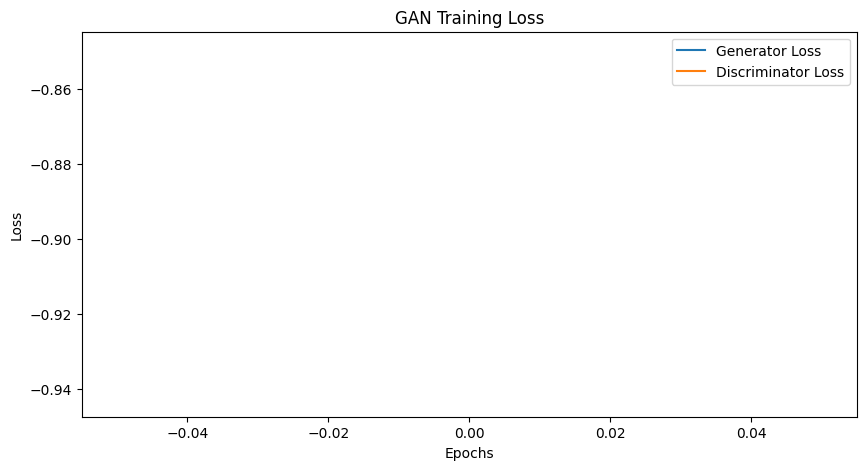

In [12]:
# --------------------
# Training Loop
# --------------------
optimizer_G = optim.Adam(generator.parameters(), lr=0.0006, betas=(0.5, 0.9))
optimizer_D = optim.Adam(discriminator.parameters(), lr=0.0004, betas=(0.5, 0.9))

n_epochs = 5  # Adjust number of epochs as needed
lambda_gp = 10
losses_G, losses_D = [], []

def plot_losses():
    plt.figure(figsize=(10, 5))
    plt.plot(losses_G, label='Generator Loss')
    plt.plot(losses_D, label='Discriminator Loss')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.title('GAN Training Loss')
    plt.show()

for epoch in range(n_epochs):
    for real_samples in data_loader:
        real_samples = real_samples.float()
        batch_size = real_samples.size(0)
        
        # Train Discriminator
        optimizer_D.zero_grad()
        z = torch.randn(batch_size, latent_dim)
        fake_samples = generator(z).detach()
        loss_D_real = -torch.mean(discriminator(real_samples))
        loss_D_fake = torch.mean(discriminator(fake_samples))
        gradient_penalty = compute_gradient_penalty(discriminator, real_samples, fake_samples)
        loss_D = loss_D_real + loss_D_fake + lambda_gp * gradient_penalty
        loss_D.backward()
        optimizer_D.step()

        # Train Generator
        optimizer_G.zero_grad()
        z = torch.randn(batch_size, latent_dim)
        fake_samples = generator(z)

        # WGAN-GP generator loss
        loss_G = -torch.mean(discriminator(fake_samples))

        # === Grammar penalty block ===
        gen_np = fake_samples.detach().cpu().numpy()
        grammar_penalties = []
        for i in range(batch_size):
            vec = gen_np[i]
            selfies_str = reconstruct_selfies(vec, dataset.max_seq_len, dataset.vocab_size, dataset.idx_to_token)
            penalty = selfies_grammar_penalty(selfies_str, dataset.max_seq_len)
            grammar_penalties.append(penalty)

        grammar_loss = torch.tensor(grammar_penalties, dtype=torch.float32).mean()
        λ = 0.5  # weight for grammar penalty

        # Total generator loss
        total_loss_G = loss_G + λ * grammar_loss
        total_loss_G.backward()
        optimizer_G.step()


        
    losses_G.append(loss_G.item())
    losses_D.append(loss_D.item())
    
    if epoch % 50 == 0:
        print(f"Epoch {epoch}, Loss D: {loss_D.item()}, Loss G: {loss_G.item()}")
        plot_losses()

In [15]:
# --------------------------------------
# Reinforcement Learning Loop (Updated)
# Optimizing for geometric frustration
# Supports both intra & intermolecular FLPs
# --------------------------------------

import torch
import numpy as np
from rdkit import Chem

# Assumes:
# - generator, optimizer_G, latent_dim, dataset
# - reconstruct_selfies (function)
# - extract_flp_features (new function that takes full flp_smiles)

rewards_history = []
best_reward = -np.inf
no_improve = 0
patience = 100
min_epochs = 300
epochs = 300
batch_size = 32

for epoch in range(epochs):
    generator.train()
    z = torch.randn(batch_size, latent_dim)
    gen_output = generator(z)

    rewards = []
    gen_np = gen_output.detach().cpu().numpy()

    for i in range(batch_size):
        reward = 0.0
        vec = gen_np[i]
        selfies_str = reconstruct_selfies(
            vec,
            dataset.max_seq_len,
            dataset.vocab_size,
            dataset.idx_to_token
        )

        try:
            smiles_str = selfies.decoder(selfies_str)
        except:
            rewards.append(-2.0)  # Invalid SELFIES
            continue

        # New: Validate SMILES string
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            rewards.append(-2.0)  # Invalid SMILES
            continue

        # Check if it's intermolecular (dot-separated)
        is_inter = '.' in smiles_str

        if is_inter:
            if smiles_str.count('.') == 1:
                reward += 1.0  # Bonus for valid pair
            else:
                reward -= 2.0  # Penalize weird cases
        else:
            reward += 0.5  # Small bonus for intramolecular FLP (no dot)

        # Extract features (works for both intra & inter)
        features = extract_flp_features(smiles_str)

        if features["charge_diff"] is None:
            reward = -1.0  # Fail-safe penalty
        else:
            reward += (
                5.0 * features["charge_diff"]
                + 0.2 * features["tpsa"]
                - 0.1 * features["rotatable_bonds"]
                + 0.3 * features["num_rings"]
            )

        rewards.append(reward)

    avg_reward = np.mean(rewards)
    rewards_history.append(avg_reward)

    # Early stopping logic
    if avg_reward > best_reward:
        best_reward = avg_reward
        no_improve = 0
    else:
        no_improve += 1

    if epoch >= min_epochs and no_improve >= patience:
        print(f"\n🛑 Early stopping at epoch {epoch} | Best Reward: {best_reward:.4f}")
        break

    # Generator update (dummy loss backprop)
    z = torch.randn(batch_size, latent_dim, requires_grad=True)
    dummy_loss = generator(z).mean()
    optimizer_G.zero_grad()
    dummy_loss.backward()
    optimizer_G.step()

    if epoch % 10 == 0:
        print(f"Epoch {epoch:3d} | Avg Reward = {avg_reward:.4f} | Best = {best_reward:.4f} | No improve = {no_improve}")

⚠️ Feature extraction failed for: OCCC1CCC(C=2)C1.C.CC=2 | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C=CC1CCC=C1CC2.O2.C=3=CC=3 | Error: too many values to unpack (expected 2)
Epoch   0 | Avg Reward = 11.9604 | Best = 11.9604 | No improve = 0
⚠️ Feature extraction failed for: NC(O)C12C=N1.C3.CCNN3C(=O)C2 | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CNC=NCN=C.O.CCC(C)C(C1)O1 | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CC#COCCNN=O.N.CCCC1NC(=O)C1C | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: O=CNCCC1NCOCC1.C.CC2OC(CC2)C=C | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C1C2NC21C.C.OC3C#C3 | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C=1COCCC#C2.C=1.CCC2COC | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CC1CC=C1C23.C2.CC=CC3C | Error: to

[17:14:02] SMILES Parse Error: unclosed ring for input: 'C1C2C3NC1CC2'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'CCOC(C4)C34'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'C=C=C1CCOCON'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'O=CC=C1C'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'C1NCCC2CC(C)N1'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'CCCCOCC2(C)O'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'C1CC2=C1C=O'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'C2(C)C=O'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'CCC1C=C1C2'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'CCC(C2C3)C3'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'C12CC2(CC13)CN'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'CCNCOC(=O)C3=C'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'NC1(O)C(COC12)C#N'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'CCC2CC=C'
[17:14:02] S

⚠️ Feature extraction failed for: O1C2CC2CC1C.C#N.CCC(C)C(C)=O | Error: too many values to unpack (expected 2)
Epoch  10 | Avg Reward = 11.1831 | Best = 11.9604 | No improve = 10
⚠️ Feature extraction failed for: CC=CC1CCC1=O.O=C.O=COC#CC | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CCCNCNC=O.O.CCCCCOC=O | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C1=CCCC1COCN.C.C2CCCC2COC | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CC1CCO1.C.NCOC(=O)C=O | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: N1C(O)C(N)C1O.C.C(C)C(C)OOC | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: COCCC1ONC1OCC.CCC.C=O | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C#CC1.O1.C#C | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C1C(C)=N1.CCC.CCCCCC=O | Error: too many values to unp

[17:14:02] SMILES Parse Error: unclosed ring for input: 'CCCC1C2=N1'
[17:14:02] SMILES Parse Error: unclosed ring for input: 'C(C)N2COC'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'C1CCCCCN2C13O2'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'CC(=O)C3=C=O'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'C1C2CCC=CC213'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'CC(O)=C3'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'C1CCC2CC3C21'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'CCC3(C)CO'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'C1C(C)C12N'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'CC3C2=C3'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'C1CC=C(O)C=O'
[17:14:03] SMILES Parse Error: unclosed ring for input: 'CC(C)C1=CCC=O'


⚠️ Feature extraction failed for: CCCC=CC=CN.O=O.CCCCCC=NC=O | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C1CCCCCC(=O)N1.O.C(C)OC(=O)C=O | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: O=CCCCC1C=C1C.CCC.C(C)CCCC=O | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CC1CCCC1=O.C.CCC(C=C2)C2 | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CCCCCNC(C)N.CCN.CCC=O | Error: too many values to unpack (expected 2)
Epoch  20 | Avg Reward = 11.5612 | Best = 11.9604 | No improve = 20
⚠️ Feature extraction failed for: O1CCCC1NO.O.OCCCCCC=C=O | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CC1CCC1NC2=CC2.O3.CCCC3CCO | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: CC12CC1OC23.O.CC3(C)CC=C | Error: too many values to unpack (expected 2)
⚠️ Feature extraction failed for: C1C2C=N2.O.C.CNCC1=C | Error: to

...

[17:14:10] SMILES Parse Error: unclosed ring for input: 'C1C=CCCCC12'
[17:14:10] SMILES Parse Error: unclosed ring for input: 'NC2=N'
[17:14:10] SMILES Parse Error: unclosed ring for input: 'CC1CCC2C=C2'
[17:14:10] SMILES Parse Error: unclosed ring for input: 'NCCCN=C1C'


Epoch 280 | Avg Reward = 2.2560 | Best = 12.2734 | No improve = 259
⚠️ Feature extraction failed for: CC(C)CC(CO1)C1N.N=CCC.O=O | Error: too many values to unpack (expected 2)


[17:14:11] SMILES Parse Error: unclosed ring for input: 'C1C(C2)C=C2'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'NCNCC1'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'C1CCCCCC=O'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'OCCCN1C=C'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'C1C(C=2)CC=2C=C'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'C=CCC1C'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'CC(C)CC12NC1C=O'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'C=CCC(C)CO2'


Epoch 290 | Avg Reward = 2.0581 | Best = 12.2734 | No improve = 269
⚠️ Feature extraction failed for: CCNCCCC1NC1C.N.CCC(C)C=O | Error: too many values to unpack (expected 2)


[17:14:11] SMILES Parse Error: unclosed ring for input: 'C1C(C)CC2NC23CC1'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'C=CCC=CCNCO3'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'CC1(C)CC(=C)N'
[17:14:11] SMILES Parse Error: unclosed ring for input: 'N=CC(C2)C12'


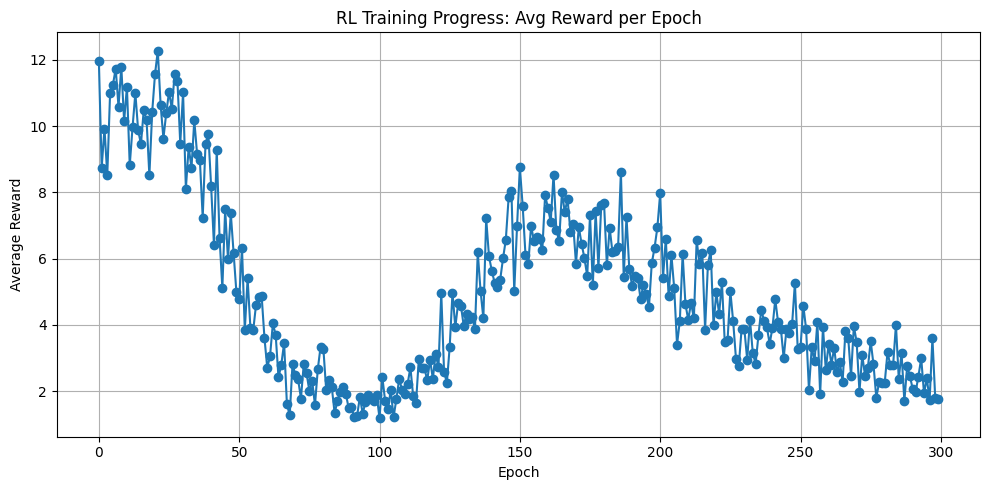

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.plot(rewards_history, marker='o', linestyle='-')
plt.xlabel("Epoch")
plt.ylabel("Average Reward")
plt.title("RL Training Progress: Avg Reward per Epoch")
plt.grid(True)
plt.tight_layout()
plt.show()

In [17]:
n_samples = 100  # Number of molecules to generate
generator.eval()  # Set the generator to evaluation mode

generated_smiles_list = set()

with torch.no_grad():
    # Generate a batch of latent vectors
    z = torch.randn(n_samples, latent_dim)
    # Generate samples from the generator
    gen_samples = generator(z).detach().cpu().numpy()
    
    # For each generated sample, reconstruct the SELFIES and convert to SMILES
    for gen_sample in gen_samples:
        selfies_str = reconstruct_selfies(gen_sample, dataset.max_seq_len, dataset.vocab_size, dataset.idx_to_token)
        smiles_str = selfies.decoder(selfies_str)
        if smiles_str != "":
            generated_smiles_list.add(smiles_str)

# Print all generated SMILES
for i, smi in enumerate(generated_smiles_list, 1):
    print(f"Molecule {i}: {smi}")

Molecule 1: CCNCCCC#C.CCC=CC(C)C=O
Molecule 2: CCCCC=CCC
Molecule 3: CC1(C)CCN=CCC1.CCC#C
Molecule 4: C1C(C)CC.C1C=CCC#CC
Molecule 5: CCCCC#C
Molecule 6: CCCCC1CC1CCCCC
Molecule 7: CC(C=1)C2C=1C2.N=CCCNC=O
Molecule 8: CCCCC=CCCCC
Molecule 9: CC=C1CCCC1CCCCCC(C2)CC2
Molecule 10: CC(C)CC1NC1C=O.CCC=C
Molecule 11: CCCCCC
Molecule 12: CC=CCCC=1CN=1
Molecule 13: C1C2(C)CC3C2COC3N1CC
Molecule 14: CCCCC1C=C1.CC(C2)C2
Molecule 15: C1C(C2)C=C2CN1CC=C=O
Molecule 16: CC1CCCC1CCCC
Molecule 17: CC=CCCCC(O)CNCOC(C)C
Molecule 18: C1C2(C3)CC3(C1CC=CC)C(=O)C2
Molecule 19: CCCCCC1CC1C=CC2CC2
Molecule 20: CCCCC=CCCC=C
Molecule 21: CCCCCCCNC=O
Molecule 22: CC=CCC1CC1=O
Molecule 23: CC=CC1CC=C(N1)NCCCC(C)C
Molecule 24: CC(C1)CC1(CC)C=CC(C)=O
Molecule 25: CCCCCCCCCCCCC
Molecule 26: C12CCCCCC1.NC2=N
Molecule 27: CCCCCCCCCC
Molecule 28: CCCC1C2CC2C1CC
Molecule 29: C12CCCCCC1.NCC=N2
Molecule 30: C1C(C)C=C1
Molecule 31: CC=CC=1CCCN=1
Molecule 32: CC=CCCC1C=C12.C2CCC
Molecule 33: CC=CC1CC2CN21
Molecule 34: CC=CC

In [18]:
from rdkit import Chem

def validate_smiles(smiles_str):
    """
    Validate a SMILES string using RDKit.
    
    Args:
        smiles_str (str): The SMILES string to validate.
        
    Returns:
        bool: True if the SMILES is valid, False otherwise.
    """
    try:
        # Convert the SMILES string into an RDKit molecule
        mol = Chem.MolFromSmiles(smiles_str)
        if mol is None:
            return False
        
        # Optional: sanitize the molecule to catch any additional issues
        Chem.SanitizeMol(mol)
        return True
    except Exception as e:
        # If any exception occurs, the SMILES is considered invalid
        return False
for i, smi in enumerate(generated_smiles_list, 1):
    print(smi)
    if validate_smiles(smi):
        print("The generated SMILES is valid!")
    else:
        print("The generated SMILES is invalid.")


CCNCCCC#C.CCC=CC(C)C=O
The generated SMILES is valid!
CCCCC=CCC
The generated SMILES is valid!
CC1(C)CCN=CCC1.CCC#C
The generated SMILES is valid!
C1C(C)CC.C1C=CCC#CC
The generated SMILES is valid!
CCCCC#C
The generated SMILES is valid!
CCCCC1CC1CCCCC
The generated SMILES is valid!
CC(C=1)C2C=1C2.N=CCCNC=O
The generated SMILES is valid!
CCCCC=CCCCC
The generated SMILES is valid!
CC=C1CCCC1CCCCCC(C2)CC2
The generated SMILES is valid!
CC(C)CC1NC1C=O.CCC=C
The generated SMILES is valid!
CCCCCC
The generated SMILES is valid!
CC=CCCC=1CN=1
The generated SMILES is valid!
C1C2(C)CC3C2COC3N1CC
The generated SMILES is valid!
CCCCC1C=C1.CC(C2)C2
The generated SMILES is valid!
C1C(C2)C=C2CN1CC=C=O
The generated SMILES is valid!
CC1CCCC1CCCC
The generated SMILES is valid!
CC=CCCCC(O)CNCOC(C)C
The generated SMILES is valid!
C1C2(C3)CC3(C1CC=CC)C(=O)C2
The generated SMILES is valid!
CCCCCC1CC1C=CC2CC2
The generated SMILES is valid!
CCCCC=CCCC=C
The generated SMILES is valid!
CCCCCCCNC=O
The generate

CCNCCCC#C.CCC=CC(C)C=O


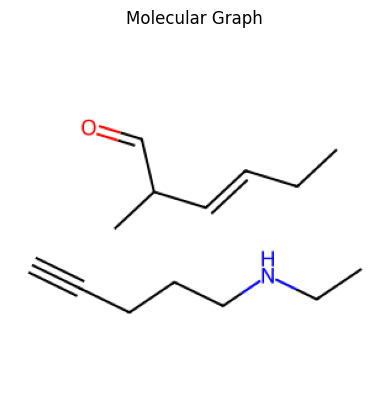

CCCCC=CCC


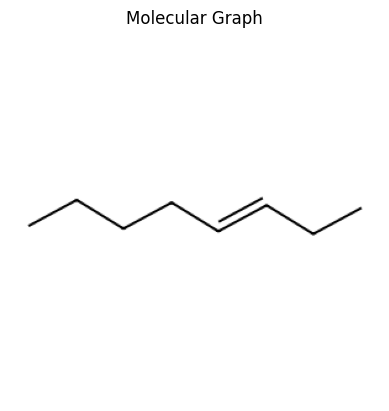

CC1(C)CCN=CCC1.CCC#C


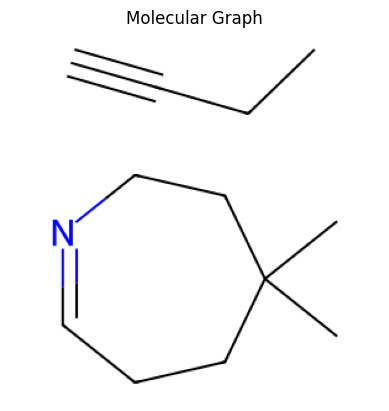

C1C(C)CC.C1C=CCC#CC


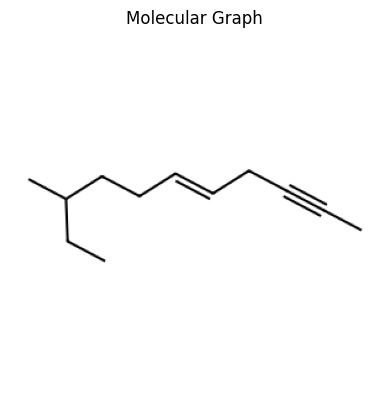

CCCCC#C


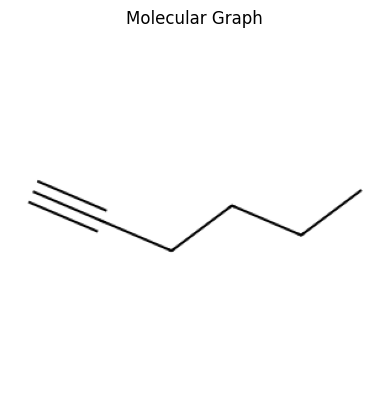

CCCCC1CC1CCCCC


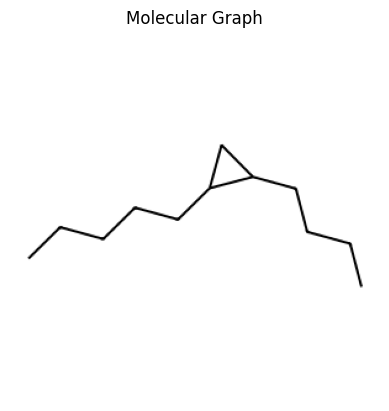

CC(C=1)C2C=1C2.N=CCCNC=O


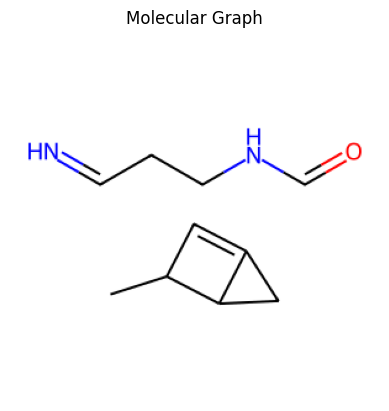

CCCCC=CCCCC


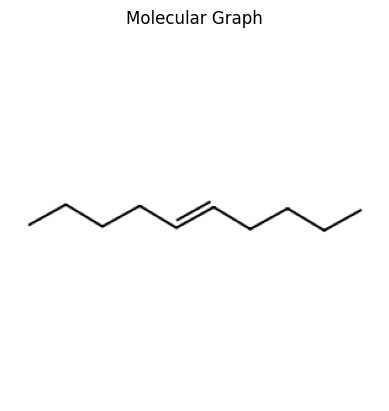

CC=C1CCCC1CCCCCC(C2)CC2


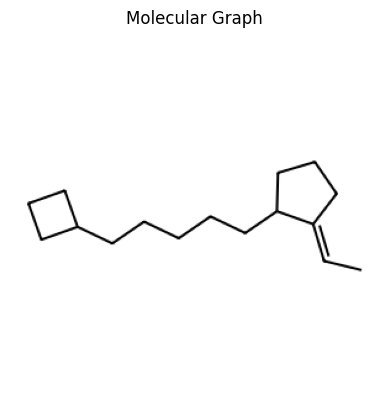

CC(C)CC1NC1C=O.CCC=C


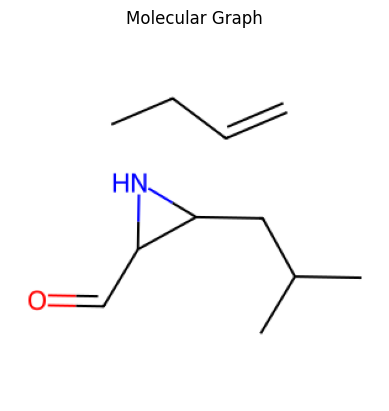

CCCCCC


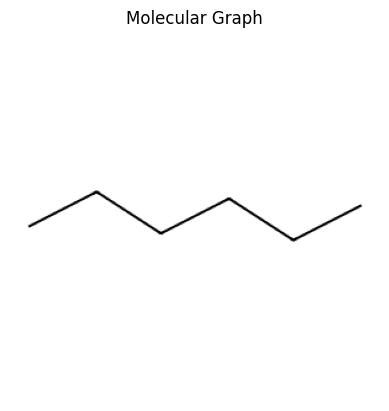

CC=CCCC=1CN=1


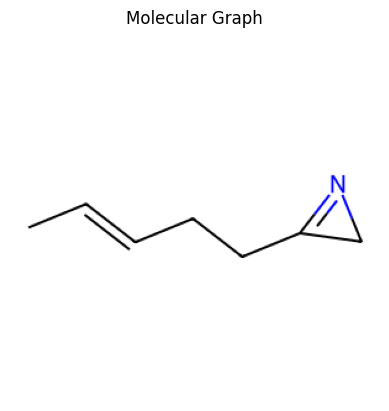

C1C2(C)CC3C2COC3N1CC


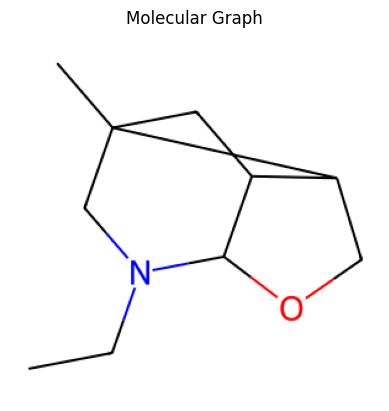

CCCCC1C=C1.CC(C2)C2


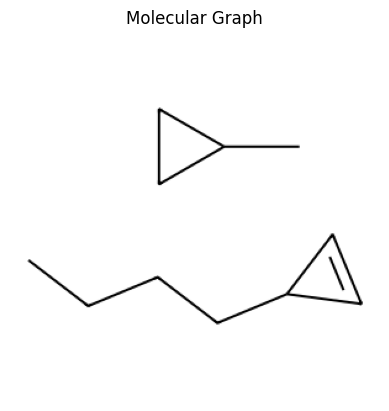

C1C(C2)C=C2CN1CC=C=O


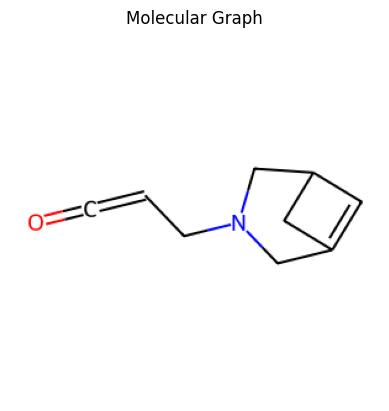

CC1CCCC1CCCC


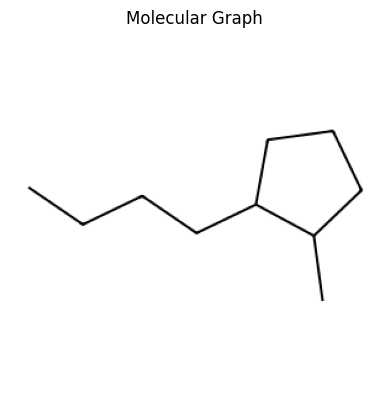

CC=CCCCC(O)CNCOC(C)C


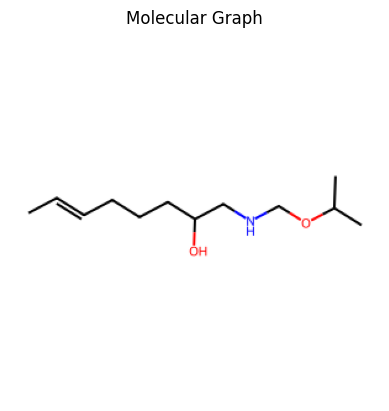

C1C2(C3)CC3(C1CC=CC)C(=O)C2


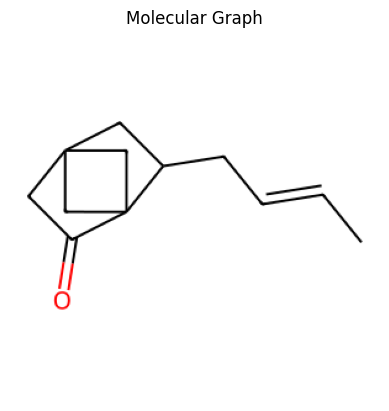

CCCCCC1CC1C=CC2CC2


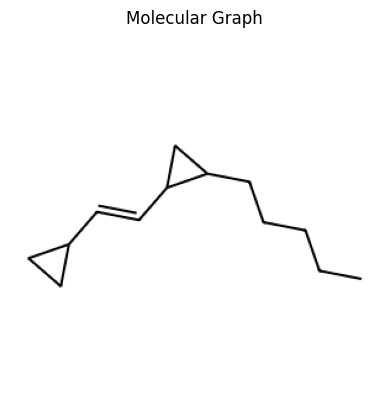

CCCCC=CCCC=C


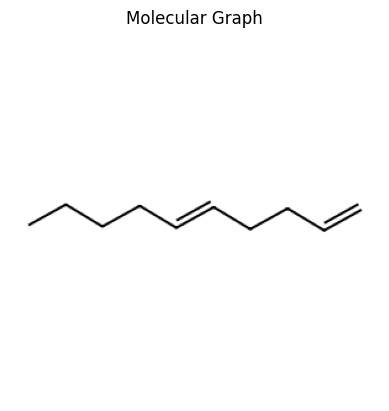

CCCCCCCNC=O


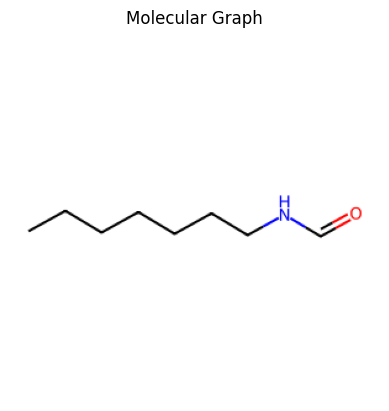

CC=CCC1CC1=O


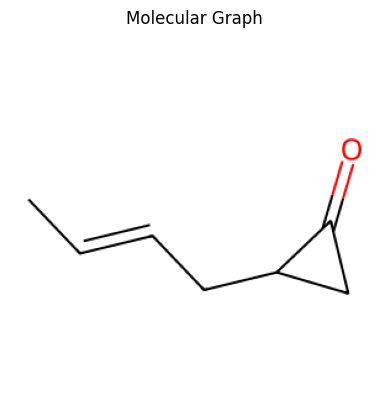

CC=CC1CC=C(N1)NCCCC(C)C


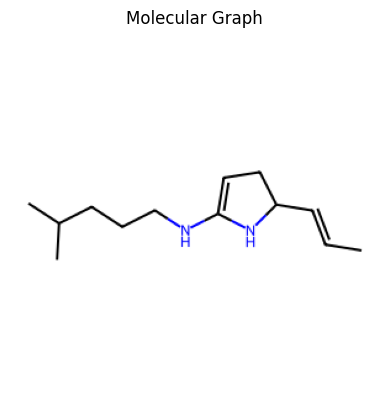

CC(C1)CC1(CC)C=CC(C)=O


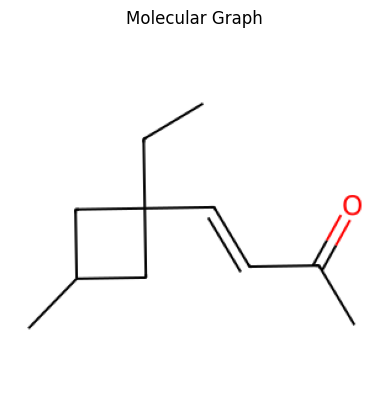

CCCCCCCCCCCCC


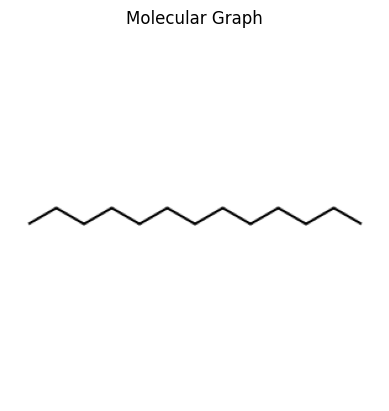

C12CCCCCC1.NC2=N


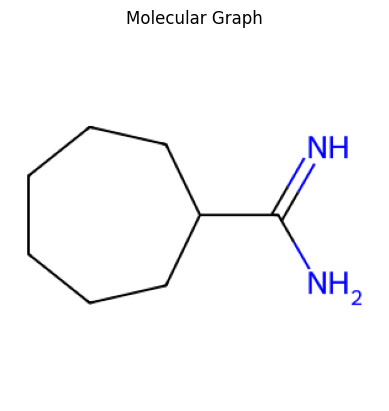

CCCCCCCCCC


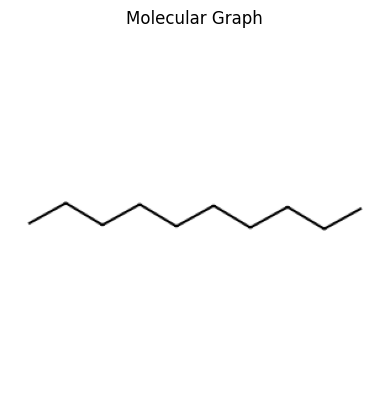

CCCC1C2CC2C1CC


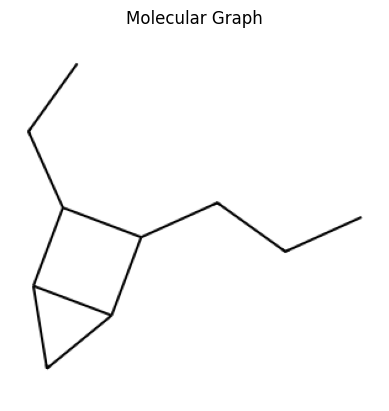

C12CCCCCC1.NCC=N2


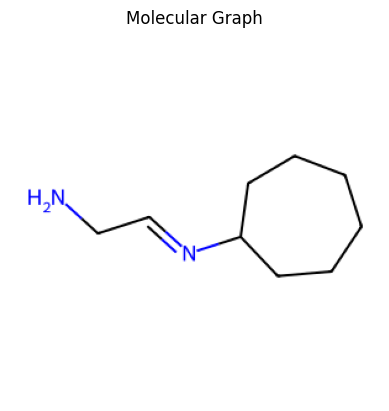

C1C(C)C=C1


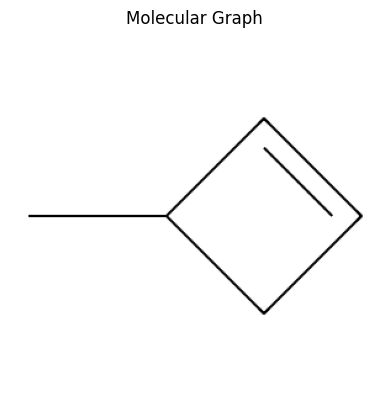

CC=CC=1CCCN=1


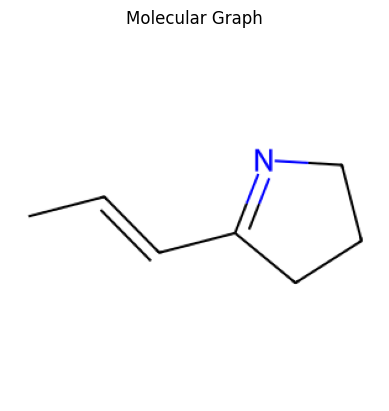

CC=CCCC1C=C12.C2CCC


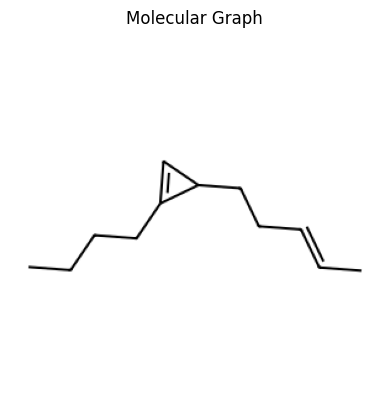

CC=CC1CC2CN21


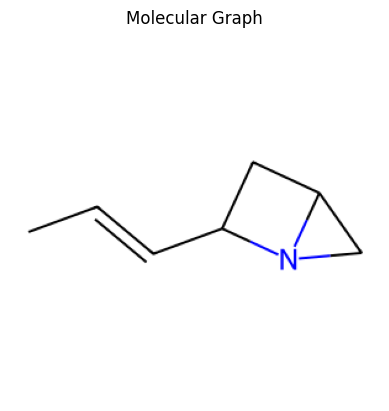

CC=CCC1CC1=CN


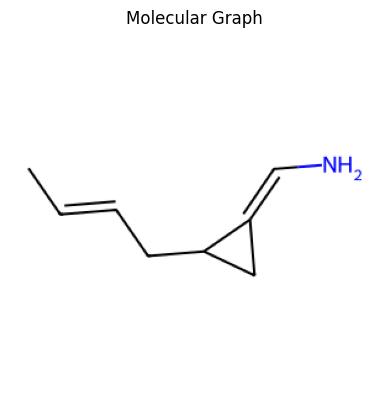

CCCCC1CC1C


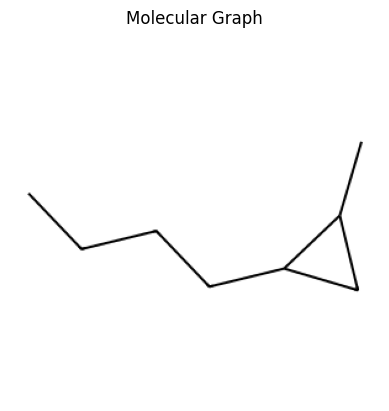

CCCCCCCC


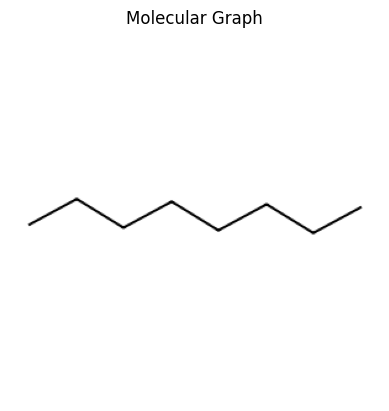

CCCCCC=C


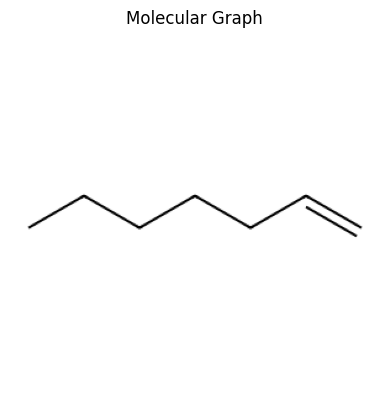

CCCCC1CC1=COCC2CC2


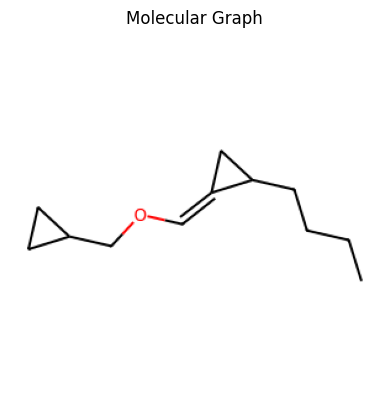

CC=CCCC=C


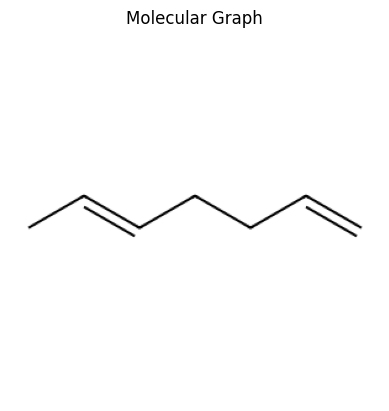

CCCCCCC1N=C1.OC=CC2=NC2


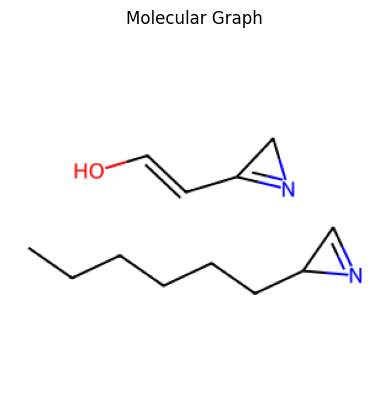

CC(C)CCN=CC.OCCCCC1=CC1=O


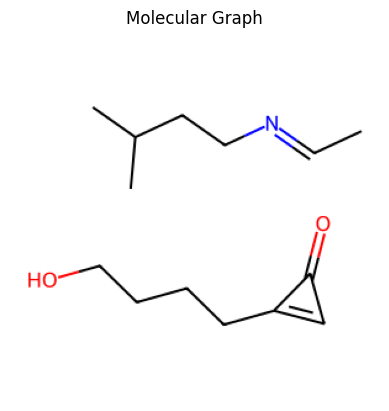

CC(C)C#C


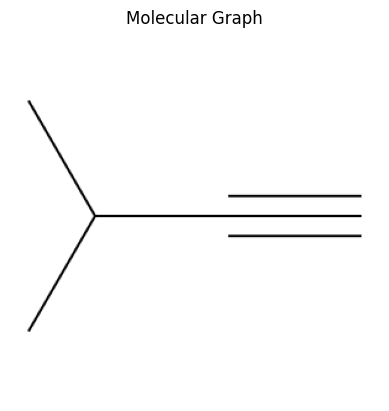

CCCCCCC


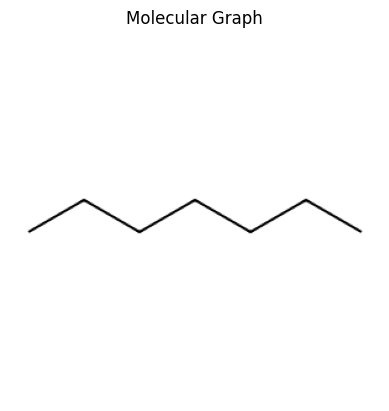

CC(C)CC(O)CNCCCC=CC


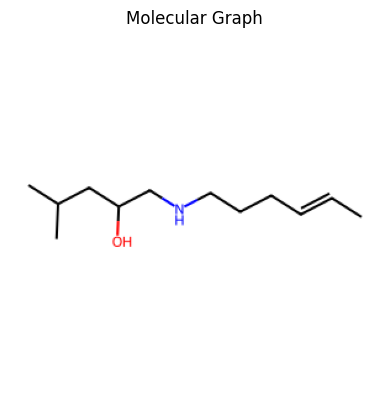

CC=CCC1C#C1


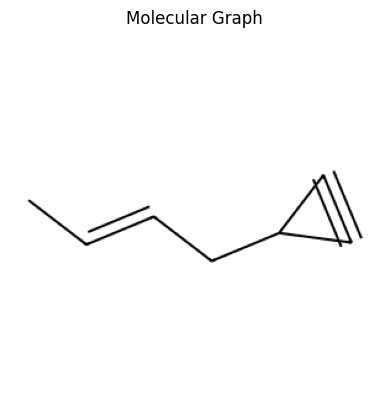

CC=C1CCCC1=CCNCCC=CCCC


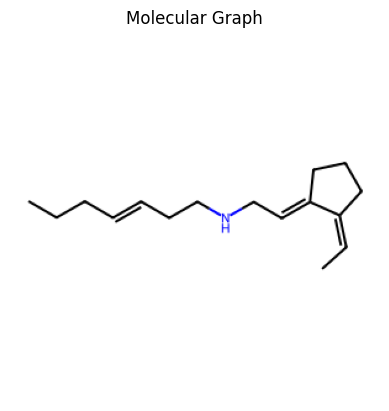

CC=CCC1C=C1CCC


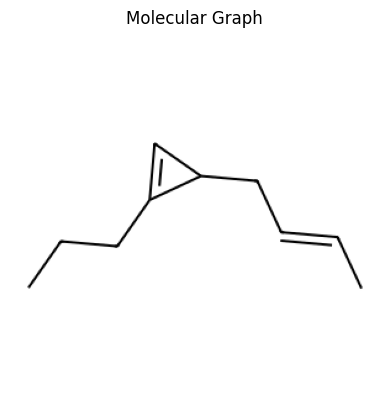

CCCCC1CC1CCCCCCC


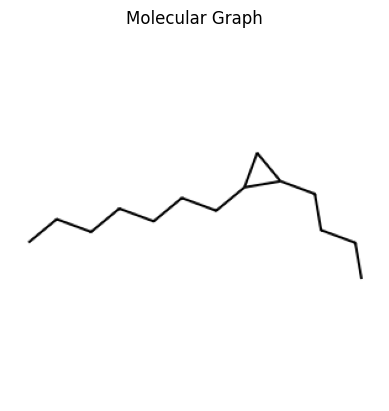

CCCCC=C


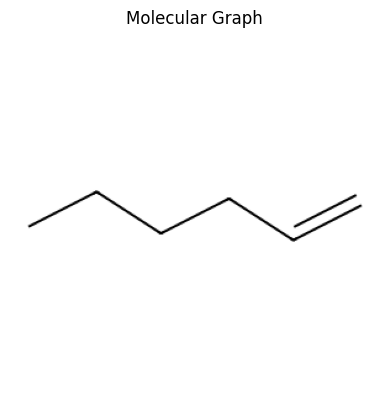

CCCCC#CC


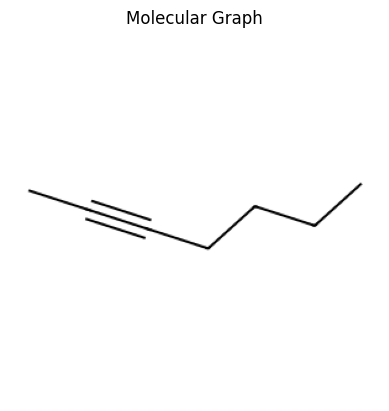

CC(C)CC=CCCC=CCC1CC1


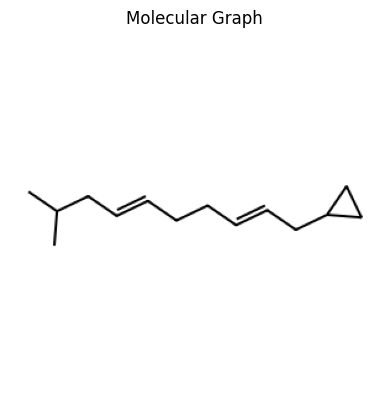

CC=CCCC=CN1C=CC=C1


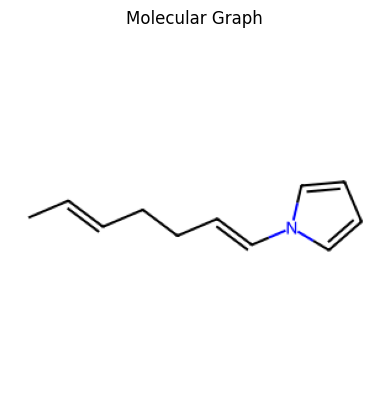

CCCCCCN(C)CC1=CC1C


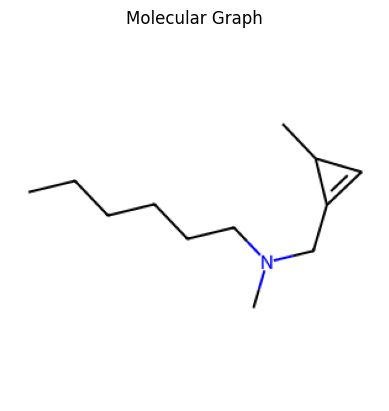

CCCC1CC1CCC


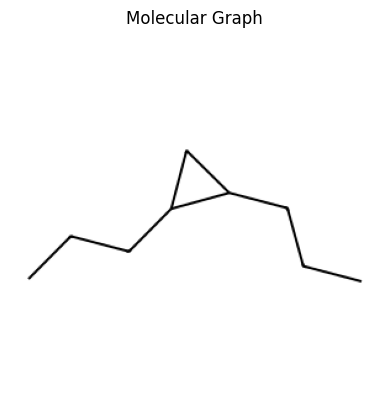

CC=CC1CCC#C1


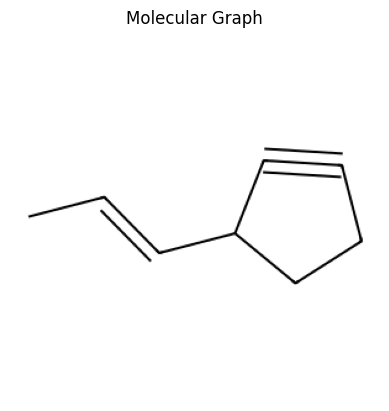

CCCCCCCCCCC


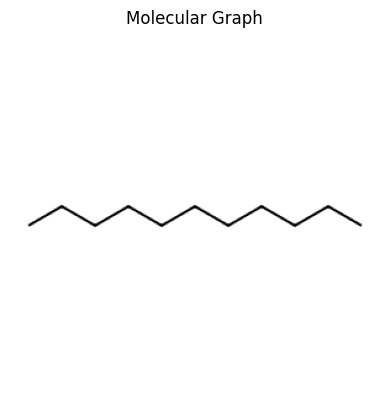

CC=CCCC=CCCCC=O


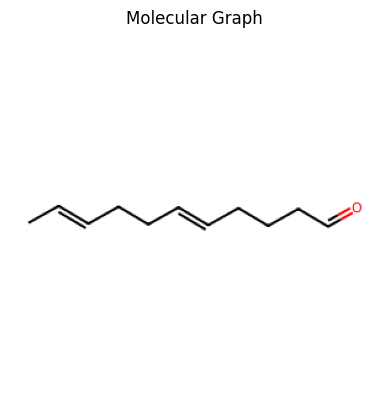

CC(C)CC=1N=C=1


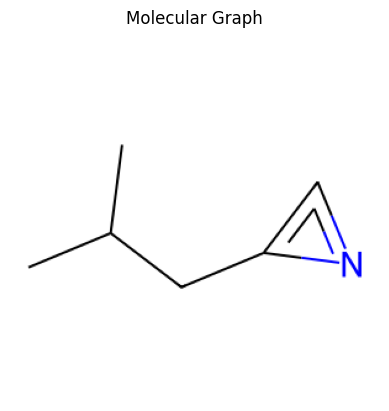

CC=CCCCCCCNCC


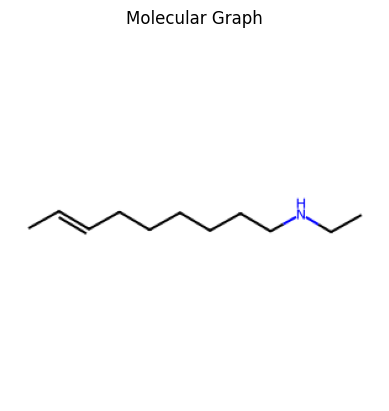

In [19]:
from rdkit import Chem
from rdkit.Chem import Draw
import matplotlib.pyplot as plt

def visualize_smiles(smiles_str):
    """
    Convert a SMILES string to an RDKit molecule and visualize it.
    
    Args:
        smiles_str (str): The SMILES string to visualize.
    """
    # Convert SMILES to an RDKit molecule
    mol = Chem.MolFromSmiles(smiles_str)
    if mol is None:
        print("Invalid SMILES string.")
        return
    
    # Option 1: Using MolToImage to create a PIL image and display it with matplotlib
    img = Draw.MolToImage(mol, size=(300, 300))
    plt.imshow(img)
    plt.axis('off')
    plt.title("Molecular Graph")
    plt.show()

for i, smi in enumerate(generated_smiles_list, 1):
    print(smi)
    visualize_smiles(smi)


In [20]:
import numpy as np
from rdkit import Chem
from rdkit.Chem import AllChem, DataStructs

def measure_uniqueness(smiles_list):
    """
    Calculates the fraction of unique SMILES.
    
    Args:
        smiles_list (list of str): A list of SMILES strings.
    
    Returns:
        float: The fraction of unique SMILES in the list.
    """
    # Filter out invalid SMILES (None after parsing)
    valid_smiles = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            valid_smiles.append(Chem.MolToSmiles(mol, isomericSmiles=True))
    # Convert to set to remove duplicates
    unique_smiles = set(valid_smiles)
    if len(valid_smiles) == 0:
        return 0.0
    return len(unique_smiles) / len(valid_smiles)

def measure_diversity(smiles_list, radius=2, nBits=1024):
    """
    Computes the average pairwise Tanimoto distance (1 - similarity) among molecules.
    A higher average distance indicates higher diversity.
    
    Args:
        smiles_list (list of str): A list of SMILES strings.
        radius (int): Radius parameter for Morgan fingerprint.
        nBits (int): Size of the fingerprint bit vector.
    
    Returns:
        float: Average pairwise Tanimoto distance (1 - similarity).
    """
    # Generate fingerprints for all valid SMILES
    fps = []
    for smi in smiles_list:
        mol = Chem.MolFromSmiles(smi)
        if mol is not None:
            fp = AllChem.GetMorganFingerprintAsBitVect(mol, radius, nBits=nBits)
            fps.append(fp)
    
    if len(fps) < 2:
        # Not enough molecules to compare
        return 0.0
    
    # Compute pairwise Tanimoto similarities
    similarities = []
    for i in range(len(fps)):
        for j in range(i + 1, len(fps)):
            sim = DataStructs.TanimotoSimilarity(fps[i], fps[j])
            similarities.append(sim)
    
    # Convert similarity to distance = 1 - similarity
    distances = [1 - sim for sim in similarities]
    
    # Return the average distance
    return np.mean(distances)



uniqueness = measure_uniqueness(generated_smiles_list)
diversity = measure_diversity(generated_smiles_list, radius=2, nBits=1024)

print(f"Uniqueness: {uniqueness:.2f}")
print(f"Average Pairwise Tanimoto Distance: {diversity:.3f}")

Uniqueness: 1.00
Average Pairwise Tanimoto Distance: 0.848


[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerator
[17:15:01] DEPRECATION WARNING: please use MorganGenerat

In [33]:
gen_df = pd.DataFrame(generated_smiles_list, columns=['smiles'])

In [34]:
gen_df

,smiles
0,CCNCCCC#C.CCC=CC(C)C=O
1,CCCCC=CCC
2,CC1(C)CCN=CCC1.CCC#C
3,C1C(C)CC.C1C=CCC#CC
4,CCCCC#C
5,CCCCC1CC1CCCCC
6,CC(C=1)C2C=1C2.N=CCCNC=O
7,CCCCC=CCCCC
8,CC=C1CCCC1CCCCCC(C2)CC2
9,CC(C)CC1NC1C=O.CCC=C


In [35]:
gen_feature_dicts = gen_df["smiles"].apply(extract_flp_features)
gen_features_df = pd.DataFrame(flp_feature_dicts.tolist())

[17:23:51] SMILES Parse Error: unclosed ring for input: 'C1C(C)CC'
[17:23:51] SMILES Parse Error: unclosed ring for input: 'C1C=CCC#CC'
[17:23:52] SMILES Parse Error: unclosed ring for input: 'C12CCCCCC1'
[17:23:52] SMILES Parse Error: unclosed ring for input: 'NC2=N'
[17:23:52] SMILES Parse Error: unclosed ring for input: 'C12CCCCCC1'
[17:23:52] SMILES Parse Error: unclosed ring for input: 'NCC=N2'
[17:23:52] SMILES Parse Error: unclosed ring for input: 'CC=CCCC1C=C12'
[17:23:52] SMILES Parse Error: unclosed ring for input: 'C2CCC'


In [36]:
gen_features_df

,charge_diff,tpsa,rotatable_bonds,num_rings
0,0.576294,43.09,0,0
1,0.583711,43.09,1,0
2,0.660903,69.11,0,0
3,0.505340,40.86,0,0
4,0.568116,29.10,1,0
...,...,...,...,...
108694,0.675774,109.48,8,1
108695,0.712023,158.39,1,2
108696,0.735245,87.99,3,3
108697,0.573001,116.49,4,2


In [37]:
flp_all_features_df = pd.concat([gen_df, gen_features_df], axis=1)

In [38]:
flp_all_features_df

,smiles,charge_diff,tpsa,rotatable_bonds,num_rings
0,CCNCCCC#C.CCC=CC(C)C=O,0.576294,43.09,0,0
1,CCCCC=CCC,0.583711,43.09,1,0
2,CC1(C)CCN=CCC1.CCC#C,0.660903,69.11,0,0
3,C1C(C)CC.C1C=CCC#CC,0.505340,40.86,0,0
4,CCCCC#C,0.568116,29.10,1,0
...,...,...,...,...,...
108694,NaN,0.675774,109.48,8,1
108695,NaN,0.712023,158.39,1,2
108696,NaN,0.735245,87.99,3,3
108697,NaN,0.573001,116.49,4,2
